In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

загрузка датасета

In [20]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
dataset = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

In [22]:
dataset.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [24]:
dataset.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


берем только числовые признаки

In [25]:
feature_cols = ['stem-height', 'stem-width']

за целевую переменную берём cap-diameter

In [26]:
X = dataset[feature_cols].copy()
y = dataset['cap-diameter'].copy()

заполняем пропуски

In [27]:
for col in feature_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

диаграммы рассеяния

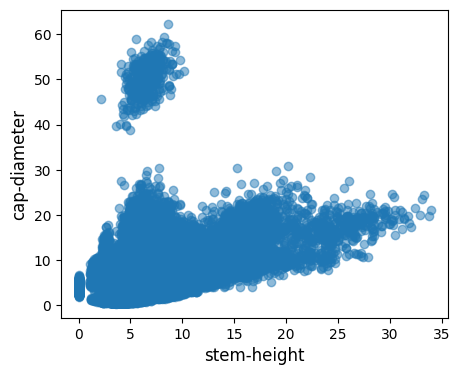

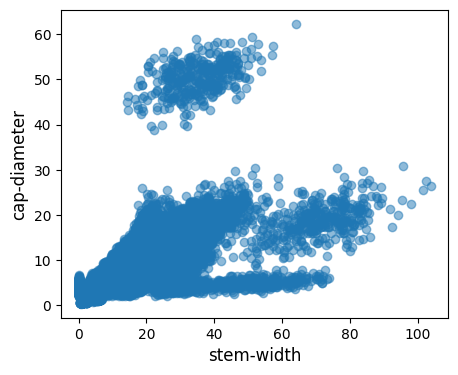

In [28]:
for index, feature_name in enumerate(feature_cols):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[feature_name], y, alpha=0.5)
    plt.ylabel('cap-diameter', size=12)
    plt.xlabel(feature_name, size=12)
    plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [30]:
def Reg_Models_Evaluation_Metrics(model, X_train, y_train, X_test, y_test, y_pred):
    cv_score = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

Линейная регрессия

In [31]:
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [32]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  3.5983
  R2: 0.5101
 Adjusted R2: 0.51
 Cross Validated R2: 0.4992


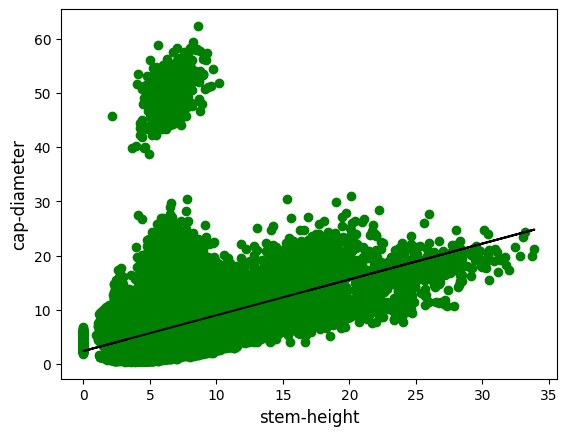

In [33]:
X2 = X[feature_cols[0]].values[:, np.newaxis]
y2 = y.values

model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2, color='g')
plt.plot(X2, model2.predict(X2), color='k')
plt.ylabel('cap-diameter', size=12)
plt.xlabel(feature_cols[0], size=12)
plt.show()

Полиномиальная регрессия

In [34]:
from sklearn.preprocessing import PolynomialFeatures

In [35]:
poly = PolynomialFeatures(degree=3, include_bias=False)

In [36]:
poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [37]:
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

In [38]:
_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  3.7179
  R2: 0.5312
 Adjusted R2: 0.531
 Cross Validated R2: 0.5513


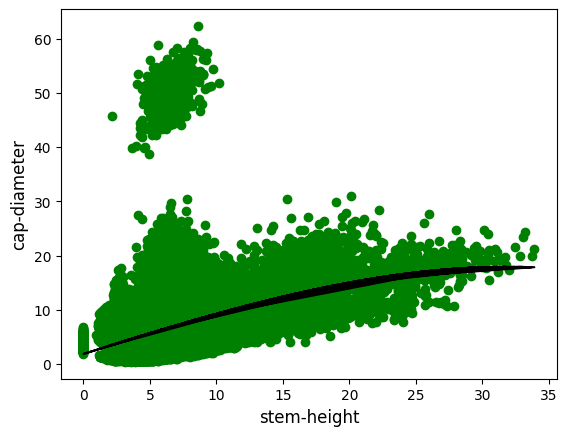

In [39]:
X2 = X[feature_cols[0]].values[:, np.newaxis]
y2 = y.values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)

plt.scatter(X2, y2, color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)), color='k')
plt.ylabel('cap-diameter', size=12)
plt.xlabel(feature_cols[0], size=12)
plt.show()

Регрессия дерева принятия решений

In [40]:
from sklearn.tree import DecisionTreeRegressor
modelDT = DecisionTreeRegressor(max_depth=10, random_state=42)
modelDT.fit(X_train, y_train)
y_dt_pred = modelDT.predict(X_test)

In [41]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  3.4043
  R2: 0.5615
 Adjusted R2: 0.5615
 Cross Validated R2: 0.5427


Регрессия случайного леса

In [42]:
modelRF = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelRF.fit(X_train, y_train)
y_rf_pred = modelRF.predict(X_test)

In [43]:
_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  3.1292
  R2: 0.6295
 Adjusted R2: 0.6295
 Cross Validated R2: 0.6154


Регрессия опорных векторов (SVR) - линейное ядро

In [45]:
from sklearn.svm import SVR

In [46]:
sample_size = min(500, len(X_train))
X_train_svr = X_train[:sample_size]
y_train_svr = y_train[:sample_size]

In [47]:
# Create a support vector regression model
modelSVR = SVR(kernel='linear', max_iter=1000)

modelSVR.fit(X_train_svr, y_train_svr)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR,X_train_svr, y_train_svr, X_test, y_test, y_rf_pred)

RMSE:  3.8354
  R2: 0.4434
 Adjusted R2: 0.4433
 Cross Validated R2: 0.3988


Регрессия ElasticNet

In [54]:
from sklearn.linear_model import ElasticNet
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)
modelEN.fit(X_train, y_train)
y_en_pred = modelEN.predict(X_test)
_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  3.5986
  R2: 0.5101
 Adjusted R2: 0.51
 Cross Validated R2: 0.4992
